# Logistic Regression Project Oefening

**DOEL: Creëer een classificatiemodel dat kan voorspellen of een persoon al dan niet een hartziekte heeft op basis van de fysieke kenmerken van die persoon. (age,sex, cholesterol, etc...)**

**Voltooi de TAKEN die hieronder vetgedrukt zijn geschreven.**

## Imports

**TAAK: Voer de cel hieronder uit om de benodigde bibliotheken te importeren.**

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

## Data

Deze database bevat 14 fysieke kenmerken gebaseerd op fysieke tests van een patiënt. Er worden bloedmonsters genomen en de patiënt ondergaat ook een korte inspanningstest. Het veld "doel" verwijst naar de aanwezigheid van hartziekten bij de patiënt. Het is een geheel getal (0 voor geen aanwezigheid, 1 voor aanwezigheid). Over het algemeen kan het 100% bevestigen of een patiënt hartziekten heeft een vrij invasief proces zijn, dus als we een model kunnen maken dat nauwkeurig de kans op hartziekten voorspelt, kunnen we dure en invasieve procedures vermijden.

Inhoud

Informatie over de attributen:
* age
* sex
* chest pain type (4 values)
* resting blood pressure
* serum cholestoral in mg/dl
* fasting blood sugar > 120 mg/dl  (nuchtere bloedsuiker)
* resting electrocardiographic results (values 0,1,2)
* maximum heart rate achieved
* exercise induced angina
* oldpeak = ST depression induced by exercise relative to rest
* the slope of the peak exercise ST segment
* number of major vessels (0-3) colored by flourosopy
* thal: 3 = normal; 6 = fixed defect; 7 = reversable defect
* target:0 for no presence of heart disease, 1 for presence of heart disease

Originele bron: https://archive.ics.uci.edu/ml/datasets/Heart+Disease

Creators:

Hungarian Institute of Cardiology. Budapest: Andras Janosi, M.D.
University Hospital, Zurich, Switzerland: William Steinbrunn, M.D.
University Hospital, Basel, Switzerland: Matthias Pfisterer, M.D.
V.A. Medical Center, Long Beach and Cleveland Clinic Foundation: Robert Detrano, M.D., Ph.D.

----

**TAAK: Voer de cel hieronder uit om de gegevens in te lezen.**

In [2]:
df = pd.read_csv('../../2_Regression/data/heart.csv')

In [4]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [5]:
df['target'].unique()

array([1, 0])

### Verkennende Gegevensanalyse en Visualisatie.

Voel je vrij om de gegevens verder op eigen initiatief te verkennen.

**TAAK: Onderzoek of de dataset ontbrekende gegevenspunten heeft en maak een statistische samenvatting van de numerieke kenmerken zoals hieronder getoond.**

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB


In [7]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,303.0,54.366337,9.082101,29.0,47.5,55.0,61.0,77.0
sex,303.0,0.683168,0.466011,0.0,0.0,1.0,1.0,1.0
cp,303.0,0.966997,1.032052,0.0,0.0,1.0,2.0,3.0
trestbps,303.0,131.623762,17.538143,94.0,120.0,130.0,140.0,200.0
chol,303.0,246.264026,51.830751,126.0,211.0,240.0,274.5,564.0
fbs,303.0,0.148515,0.356198,0.0,0.0,0.0,0.0,1.0
restecg,303.0,0.528053,0.525860,0.0,0.0,1.0,1.0,2.0
thalach,303.0,149.646865,22.905161,71.0,133.5,153.0,166.0,202.0
exang,303.0,0.326733,0.469794,0.0,0.0,0.0,1.0,1.0
oldpeak,303.0,1.039604,1.161075,0.0,0.0,0.8,1.6,6.2


,count,mean,std,min,25%,50%,75%,max
age,303.0,54.366337,9.082101,29.0,47.5,55.0,61.0,77.0
sex,303.0,0.683168,0.466011,0.0,0.0,1.0,1.0,1.0
cp,303.0,0.966997,1.032052,0.0,0.0,1.0,2.0,3.0
trestbps,303.0,131.623762,17.538143,94.0,120.0,130.0,140.0,200.0
chol,303.0,246.264026,51.830751,126.0,211.0,240.0,274.5,564.0
fbs,303.0,0.148515,0.356198,0.0,0.0,0.0,0.0,1.0
restecg,303.0,0.528053,0.525860,0.0,0.0,1.0,1.0,2.0
thalach,303.0,149.646865,22.905161,71.0,133.5,153.0,166.0,202.0
exang,303.0,0.326733,0.469794,0.0,0.0,0.0,1.0,1.0
oldpeak,303.0,1.039604,1.161075,0.0,0.0,0.8,1.6,6.2


### Visualisatietaken

**TAAK: Maak een staafdiagram dat de totale tellingen per doelwaarde toont.**

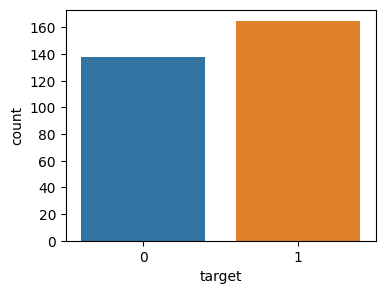

In [42]:
plt.figure(figsize=(4, 3))
sns.countplot(data=df, x='target', hue='target', legend=False)
plt.yticks(np.arange(0, 170, 20))
plt.show()


<AxesSubplot:xlabel='target', ylabel='count'>

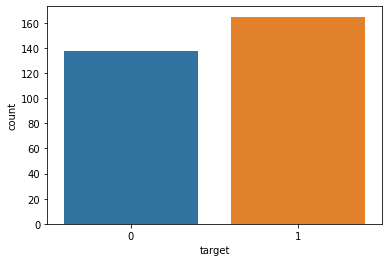

**TAAK: Maak een pairplot die de relaties toont tussen de volgende kolommen:**

    ['age','trestbps', 'chol','thalach','target']
   
*Opmerking: Een pairplot uitvoeren op alles kan erg lang duren vanwege het aantal kenmerken*

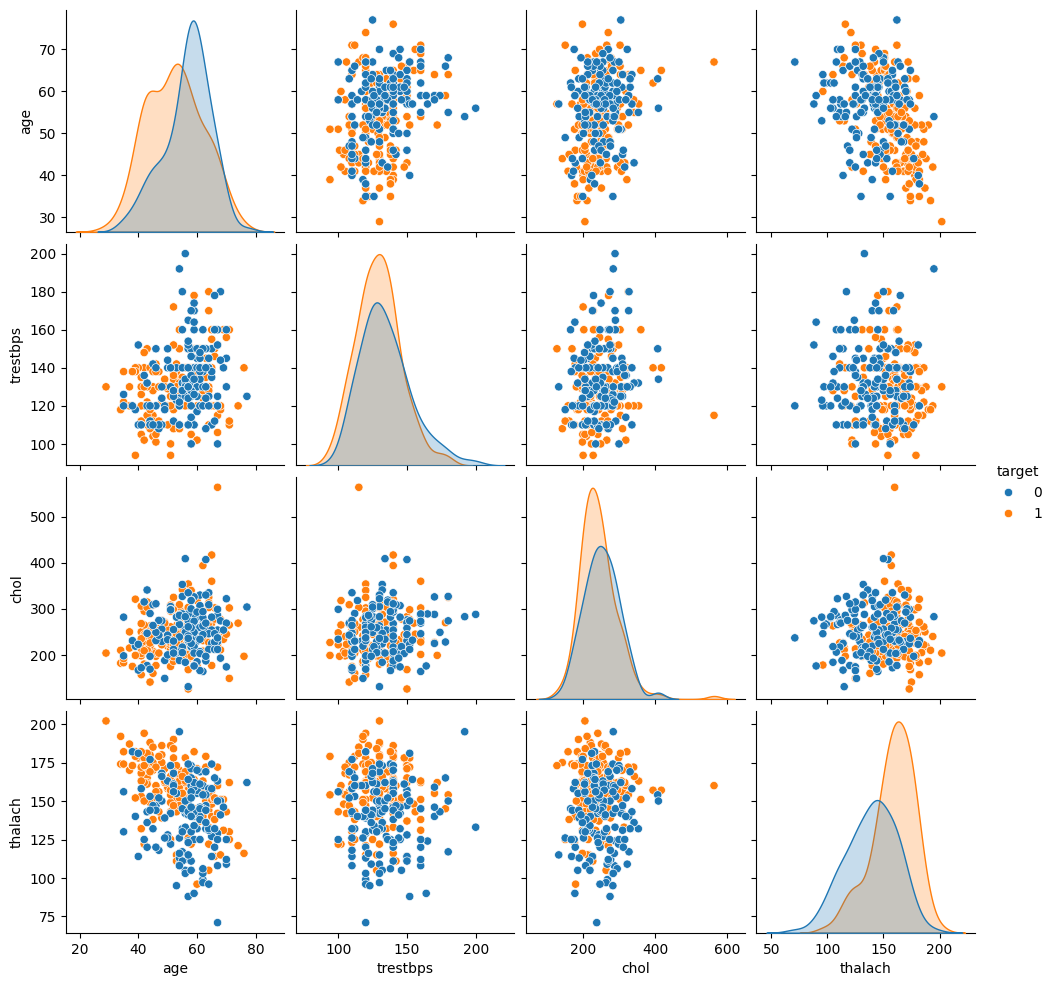

In [51]:
sns.pairplot(df, vars=['age','trestbps', 'chol','thalach'], hue="target")


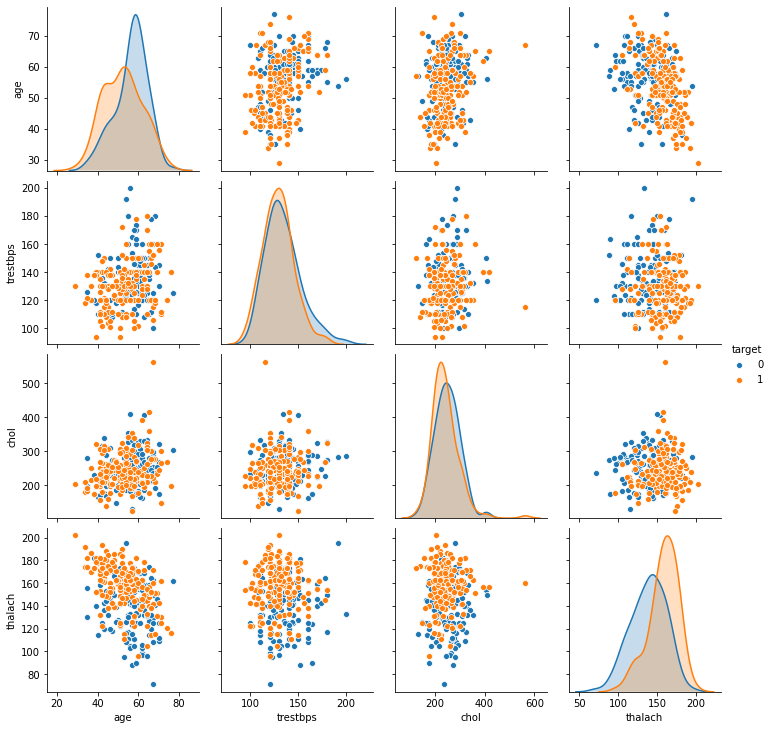

**TAAK: Maak een heatmap die de correlatie toont tussen alle kolommen.**

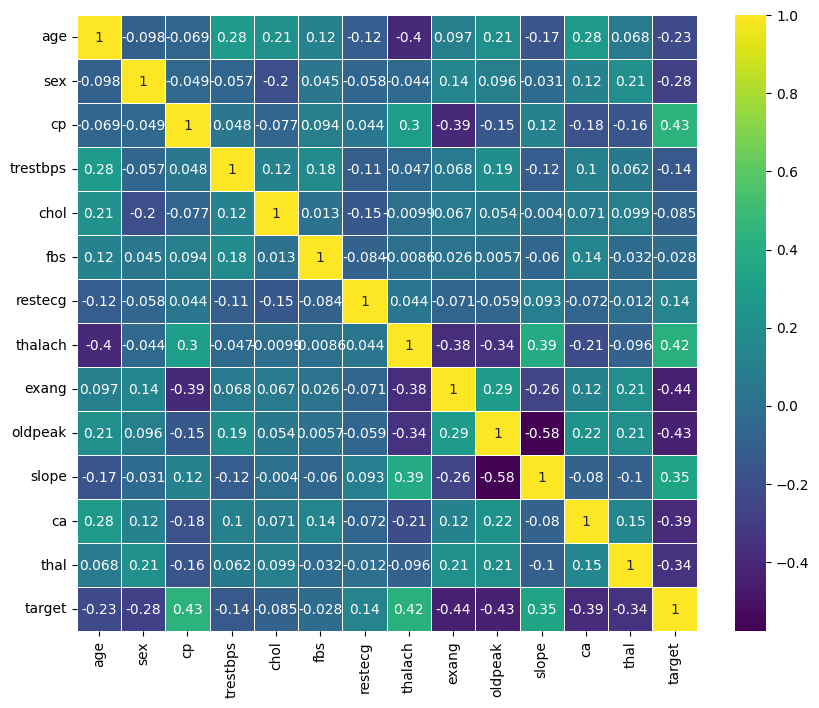

In [57]:
df_corr = df.corr()
plt.figure(figsize=(10, 8))
sns.heatmap(
    df_corr,
    annot=True,
    cmap='viridis',
    linewidths=0.5
    )

plt.show()

<AxesSubplot:>

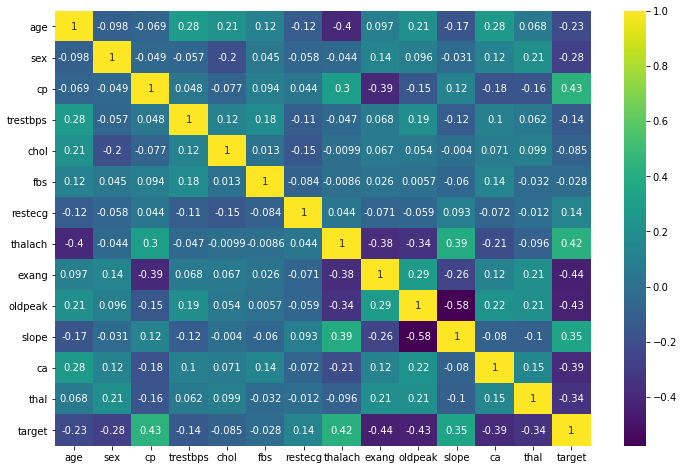

----
----

# Machine Learning

## Train | Test Split en Scaling

**TAAK: Splits de features en de labels in 2 objecten X and y.**

In [8]:
X, y = df.drop(["target"], axis=1), df["target"]

**TAAK: Voer een train-test splitsing uit op de gegevens, met een testgrootte van 10% en een random_state van 101.**

In [9]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=101)

In [10]:
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(272, 13) (31, 13) (272,) (31,)


**TAAK: Maak een StandardScaler object en normaliseer de X train en test set kenmerkgegevens. Zorg ervoor dat je alleen fit op de trainingsgegevens om een datalek te voorkomen (kennis lekken vanuit de testset).**

In [11]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

In [12]:
scaler.fit(X_train)

,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True


In [13]:
X_train = scaler.transform(X_train)
X_test = scaler.transform(X_test)

## Logistic Regression Model

**TAAK: Maak een logistiek regressiemodel en gebruik kruisvalidatie om een goed presterende C-waarde te vinden voor de hyperparameter-zoekopdracht. Je hebt hier twee opties: gebruik LogisticRegressionCV OF gebruik een combinatie van LogisticRegression en GridSearchCV. De keuze is aan jou.**

In [14]:
from sklearn.linear_model import LogisticRegression, LogisticRegressionCV
from sklearn.model_selection import GridSearchCV

In [75]:
#help(LogisticRegressionCV)
#help(GridSearchCV)

In [15]:
# Proberen GridSearchCV
# Possible solvers: 'liblinear', 'lbfgs', 'saga', 'newton-cg' (does not support L2)
# (with penalty param got FutureWarning: Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None. And UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0.)

param_grid = {
    'C': [0.1, 1, 10],
    'l1_ratio': [1.0, 0.0],
    'solver': ['liblinear', 'saga']
    }
cv = 5
metric = "accuracy"

gscv = GridSearchCV(
    estimator=LogisticRegression(random_state=101),
    param_grid=param_grid,
    cv=cv,
    scoring=metric)
gscv.fit(X_train, y_train)

print(f"GridSearchCV best score: {gscv.best_score_:.2f}")

GridSearchCV best score: 0.84


In [17]:
# Proberen LogisticRegressionCV with this best params?

lrcv = LogisticRegressionCV(
       Cs=param_grid['C'][1],
       l1_ratios=(1,),
       scoring=metric,
       cv=cv,
       solver=param_grid['solver'][0],
       max_iter=1000,
       use_legacy_attributes=False
    )
lrcv.fit(X_train, y_train)
print(f"LogisticRegressionCV best score: {lrcv.scores_[1].mean(axis=0).max():.2f}")

LogisticRegressionCV best score: 0.45


In [ ]:
# Oops, GridSearchCV'accuracy looks much better

LogisticRegressionCV()

**TAAK: Rapporteer de optimale parameters van je zoekopdracht, specifiek de C-waarde.** 

*Opmerking: Afhankelijk van hoe je je zoekopdracht hebt uitgevoerd, kun je een andere waarde krijgen.*

In [18]:
print(f"GridSearchCV best hyperparameters: {gscv.best_params_}")

GridSearchCV best hyperparameters: {'C': 1, 'l1_ratio': 1.0, 'solver': 'liblinear'}


### Coëfficiënten

**TAAK: Repporteer de coëfficiënten van het model.**

In [19]:
best_model = gscv.best_estimator_
best_model.coef_

array([[-0.04308742, -0.69020247,  0.88888524, -0.23944377, -0.1865055 ,
         0.        ,  0.09806666,  0.42706967, -0.40900078, -0.53067323,
         0.35415155, -0.83615177, -0.56678905]])

array([[-0.09621199, -0.39460154,  0.53534731, -0.13850191, -0.08830462,
         0.02487341,  0.08083826,  0.29914053, -0.33438151, -0.352386  ,
         0.25101033, -0.49735752, -0.37448551]])

**BONUS TAAK: Dit heb ik niet getoond in de notebooks, maar je kan dit ongetwijfeld zelf vinden! Maak een visualisatie van de coëfficiënten door gebruik te maken van een staafdiagram van hun waarden. Zoek ook uit hoe je de plot kunt sorteren! Er zijn veel manieren om dit te doen, de oplossingen gebruiken een combinatie van pandas en seaborn.**

In [157]:
# Linking features to the coefficients

coef_feats = pd.DataFrame({"features": df.columns[:-1], "coefs": best_model.coef_[0]})
coef_feats = coef_feats.sort_values(by="coefs")
coef_feats

,features,coefs
11,ca,-0.836152
1,sex,-0.690202
12,thal,-0.566789
9,oldpeak,-0.530673
8,exang,-0.409001
3,trestbps,-0.239444
4,chol,-0.186505
0,age,-0.043087
5,fbs,0.000000
6,restecg,0.098067


<function matplotlib.pyplot.show(close=None, block=None)>

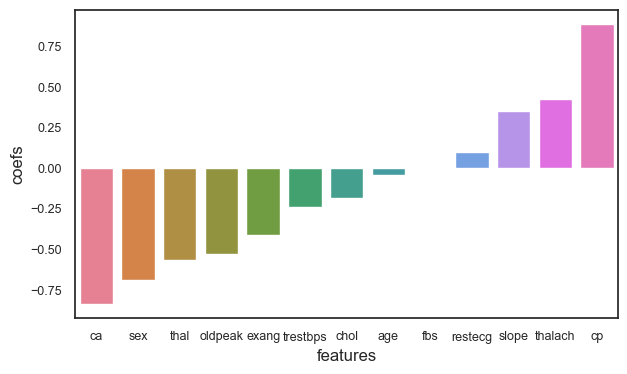

In [145]:
plt.figure(figsize=(7, 4))
sns.barplot(x="features", y="coefs", data=coef_feats, hue="features")
plt.xticks(fontsize=9)
plt.yticks(fontsize=9)
plt.show

In [ ]:
# bij me zijn de coefficienten lichtjes anders en fbs is 0, daarom het kleine verschil in bars en die lelijke spatie :(

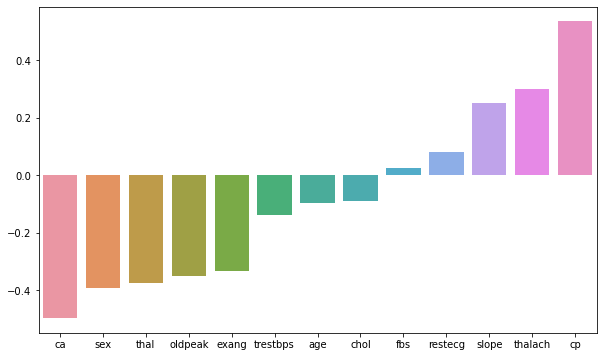

---------

## Evaluatie van de model performantie

**TAAK: Laten we nu je model evalueren op de overige 10% van de gegevens, de testset.**

**TAAK: Maak de volgende evaluaties:**
* Confusion Matrix Array
* Confusion Matrix Plot
* Classification Report

In [20]:
from sklearn.metrics import confusion_matrix

y_pred = best_model.predict(X_test)
cnf_matrix = confusion_matrix(y_test, y_pred)
cnf_matrix

array([[12,  3],
       [ 2, 14]])

array([[12,  3],
       [ 2, 14]], dtype=int64)

Text(0.5, 4.249999999999995, 'Predicted label')

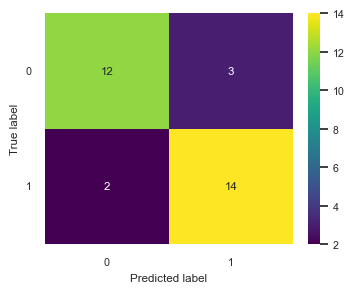

In [175]:
sns.set_theme(rc={"figure.figsize": (4, 3)}, font_scale=0.7)
sns.heatmap(cnf_matrix, annot=True, cmap="viridis")
plt.ylabel("True label")
plt.yticks(rotation=0)
plt.xlabel("Predicted label")

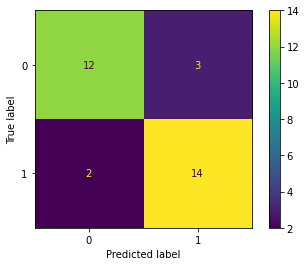

In [176]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.86      0.80      0.83        15
           1       0.82      0.88      0.85        16

    accuracy                           0.84        31
   macro avg       0.84      0.84      0.84        31
weighted avg       0.84      0.84      0.84        31



              precision    recall  f1-score   support

           0       0.86      0.80      0.83        15
           1       0.82      0.88      0.85        16

    accuracy                           0.84        31
   macro avg       0.84      0.84      0.84        31
weighted avg       0.84      0.84      0.84        31



### Performance Curves

**TAAK: Maak zowel de precision recall als de ROC Curve.**

In [21]:
from sklearn.metrics import precision_recall_curve, PrecisionRecallDisplay, RocCurveDisplay

(0.5, 1.1)

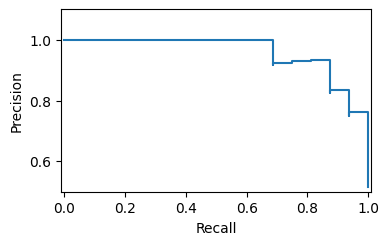

In [40]:
fig, ax = plt.subplots(figsize=(4, 4))
y_prob = best_model.predict_proba(X_test)
y_prob = y_prob[:, 1] # klasse 1 kans
precision, recall, _ = precision_recall_curve(y_test, y_prob)
disp = PrecisionRecallDisplay(precision=precision, recall=recall)
disp.plot(ax=ax)
ax.set_ylim(0.5, 1.1)

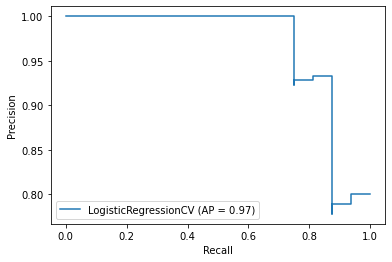

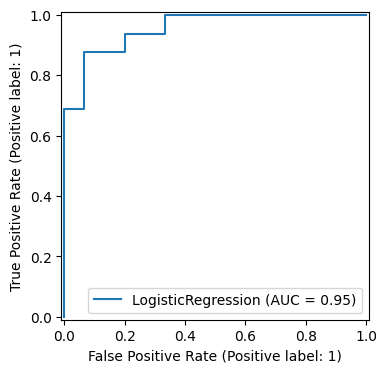

In [51]:
fig, ax = plt.subplots(figsize=(4, 4))
RocCurveDisplay.from_estimator(best_model, X_test, y_test, ax=ax)

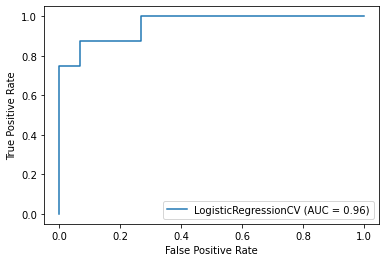

**Eindtaak: Een patiënt met de volgende kenmerken is het medisch centrum binnengekomen:**

    age          48.0
    sex           0.0
    cp            2.0
    trestbps    130.0
    chol        275.0
    fbs           0.0
    restecg       1.0
    thalach     139.0
    exang         0.0
    oldpeak       0.2
    slope         2.0
    ca            0.0
    thal          2.0

**TAAK: Wat voorspelt uw model voor deze patiënt? Hebben ze hartziekte? Hoe "zeker" is uw model van deze voorspelling?**

*Voor je gemak heb ik een array van de kenmerken voor de patiënt hierboven gemaakt.*

In [68]:
patient = [[ 54. ,   1. ,   0. , 122. , 286. ,   0. ,   0. , 116. ,   1. ,
          3.2,   1. ,   2. ,   2. ]]

In [1]:
# CODE HERE

In [6]:
# VERWACHTE UITKOMST

In [72]:
# EXPECTED PROBABILITY PER CLASS (Basically model should be extremely sure its in the 0 class)

array([[9.99999862e-01, 1.38455917e-07]])

----

## Je bent er!!